# Modeling Pipeline
## UAE E-Commerce Fraud Detection Model

In this notebook, we build and evaluate machine learning models to detect fraudulent transactions.
We use a pipeline-based approach to ensure consistent preprocessing across all models and prevent data leakage.
All preprocessing decisions are based on findings from EDA and Feature Engineering notebooks.

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             roc_curve, average_precision_score, f1_score,
                             precision_score, recall_score)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import shap  
import joblib
import cloudpickle
import json
import re
import os
import psycopg2
from datetime import datetime


---
## 2. Load Data

In [2]:
main_df=pd.read_csv("../data/uae_ecom_fraud_100k.csv")

df = main_df.copy()

---
## 3. Train / Test Split


In [3]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print()
print('Fraud rate in train:', y_train.mean().round(4))
print('Fraud rate in test :', y_test.mean().round(4))

Train size: (80000, 35)
Test size : (20000, 35)

Fraud rate in train: 0.0821
Fraud rate in test : 0.0821


---
## 4. Custom Transformers
Custom transformers learn parameters from training data only — preventing data leakage into test set.
### 4.1 OutlierCapper

In [4]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Caps each column at a given lower and upper percentile.
    Boundaries are computed from training data only.
    """
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            self.lower_bounds_[col] = X[col].quantile(self.lower_pct)
            self.upper_bounds_[col] = X[col].quantile(self.upper_pct)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].clip(lower=self.lower_bounds_[col],
                                 upper=self.upper_bounds_[col])
        return X

### 4.2 SkewnessTransformer

In [5]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=1.0):
        self.threshold = threshold
        self.skewed_cols_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.skewed_cols_ = [
            col for col in X.columns
            if X[col].skew() > self.threshold and X[col].min() >= 0
        ]
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.skewed_cols_:
            X[col] = np.log1p(X[col])
        return X

---
## 5. Build Pipelines
We build separate pipelines for tree-based models and Logistic Regression. Each pipeline handles preprocessing and the model in one object.
### 5.1 Feature Engineering Transformer

In [6]:
# constants — defined outside the class

# DROP before feature engineering — not needed at all
DROP_COLS_1 = [
    'user_id', 'transaction_id', 'ip_address',
    'currency', 'data_source', 'card_present',
    'user_prev_chargebacks', 'user_std_amount', 'user_max_amount', # 'user_txn_count'
]

# DROP after feature engineering — replaced by engineered features
DROP_COLS_2 = [
    'timestamp_utc', 'email_domain',
    'fraud_flag_velocity', 'local_hour',
    'transactions_last_24h', 'transactions_last_1h',
    'is_weekend', 'billing_city', 'shipping_city',
    'fraud_flag_odd_hour', 'fraud_flag_ip', 'fraud_flag_mismatch',
    'fresh_high_value', 'night_high_risk', 'high_amount', 'risk_velocity',
    'amount_aed', 'velocity_ratio', 'browser', 'day_of_week', 'payment_method',
    'hour_bin', 'merchant_category', 'device_type'
]

FLAG_COLS = [
    'fraud_flag_ip', 'fraud_flag_mismatch',
    'fraud_flag_new_account', 'fraud_flag_prev_cb', 'fraud_flag_odd_hour'
]

CAT_COLS = [
    'payment_method', 'device_type', 'browser', 'merchant_category',
    'shipping_city', 'billing_city', 'bin_country'
]

DISPOSABLE_DOMAINS = ['tempmail', '10minutemail', 'disposable', 'mailinator', 'guerrillamail']

abs_col= ['user_account_age_days']

In [7]:
class AbsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        if self.col in X.columns:
            X[self.col] = X[self.col].abs()

        return X

In [8]:
class FraudFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Applies all feature engineering steps identified in EDA.
    Follows the correct order:
        Drop unnecessary → Feature Engineering → Encoding → Drop engineered-away cols
    Parameters are learned from training data only — no leakage.
    """
    def __init__(self, drop_flags=False,
                 drop_cols_1=None, drop_cols_2=None):
        self.drop_flags  = drop_flags
        self.drop_cols_1 = drop_cols_1 if drop_cols_1 is not None else DROP_COLS_1
        self.drop_cols_2 = drop_cols_2 if drop_cols_2 is not None else DROP_COLS_2

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        # drop cols_1 before anything
        X = X.drop(columns=[c for c in self.drop_cols_1 if c in X.columns])

        # label encoders — learned from train only
        self.encoders_ = {}
        for col in CAT_COLS:
            if col in X.columns:
                le = LabelEncoder()
                le.fit(X[col].astype(str))
                self.encoders_[col] = le

        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()

        # --- STEP 1: Drop cols before feature engineering ---
        X = X.drop(columns=[c for c in self.drop_cols_1 if c in X.columns])

        # --- STEP 2: Feature Engineering ---

        # ratio features
        X['amount_per_item_price'] = X['amount_aed'] / X['avg_item_price']
        X['amount_per_card_age']   = X['amount_aed'] / (X['card_age_days'] + 1)

        # interaction features
        X['amount_x_risk']    = X['amount_aed'] * X['ip_risk_score']
        X['fresh_high_value'] = ((X['user_account_age_days'] < 14) &
                                  (X['amount_aed'] > 1000)).astype(int)

        # new risk features
        X['high_amount']     = (X['amount_aed'] > 2000).astype(int)
        X['risk_velocity']   = X['ip_risk_score'] * X['transactions_last_1h']
        X['night_high_risk'] = ((X['odd_hour'] == 1) & (X['ip_risk_score'] > 70)).astype(int)

        # behavioral features
        X['velocity_ratio'] = X['transactions_last_1h'] / (X['transactions_last_24h'] + 1)

        # time features
        X['timestamp_utc'] = pd.to_datetime(X['timestamp_utc'])
        X['day_of_week']   = X['timestamp_utc'].dt.dayofweek
        X['is_weekend']    = X['day_of_week'].isin([5, 6]).astype(int)
        X['hour_bin']      = pd.cut(X['local_hour'], bins=[0, 6, 12, 18, 24],
                                    labels=[0, 1, 2, 3], right=False).astype(int)

        # risk aggregation
        X['combined_risk_score'] = X[FLAG_COLS].sum(axis=1)

        # email features
        X['is_disposable_email'] = X['email_domain'].str.contains(
            '|'.join(DISPOSABLE_DOMAINS), case=False, na=False).astype(int)

        # --- STEP 3: Encoding ---
        for col, le in self.encoders_.items():
            X[col] = X[col].astype(str).map(
                lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
            )

        # --- STEP 4: Drop cols after feature engineering ---
        X = X.drop(columns=[c for c in self.drop_cols_2 if c in X.columns])

        if self.drop_flags:
            flags = [c for c in FLAG_COLS + ['combined_risk_score'] if c in X.columns]
            X = X.drop(columns=flags)

        return X

### 5.2 Build Pipeline Function

In [9]:
def build_pipeline(model, is_logistic=False, drop_flags=False):
    
    steps = [('abs_transform', AbsTransformer(col='user_account_age_days')), 
            ('feature_engineering', FraudFeatureEngineer(drop_flags=drop_flags))]

    if is_logistic:
        steps.append(('cap_outliers', OutlierCapper()))
        steps.append(('skew_transform', SkewnessTransformer()))
        steps.append(('scaler', StandardScaler()))

    steps.append(('model', model))
    return Pipeline(steps)

### 5.3 Define Models

In [10]:
models = {
    'LR_with_flags'   : (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True, False),
    'LR_no_flags'     : (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True, True),
    'RF_with_flags'   : (RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42), False, False),
    'RF_no_flags'     : (RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42), False, True),
    'XGB_with_flags'  : (XGBClassifier(scale_pos_weight=10, n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='auc'), False, False),
    'XGB_no_flags'    : (XGBClassifier(scale_pos_weight=10, n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='auc'), False, True),
    'LGBM_with_flags' : (LGBMClassifier(class_weight='balanced', n_estimators=200, num_leaves=31, learning_rate=0.1, min_child_samples=20, random_state=42), False, False),
    'LGBM_no_flags'   : (LGBMClassifier(class_weight='balanced', n_estimators=200, num_leaves=31, learning_rate=0.1, min_child_samples=20, random_state=42), False, True),
}

---
## 6. Train All Models
We use StratifiedKFold cross validation to get reliable performance estimates while preserving class imbalance ratio.

In [11]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, is_logistic, drop_flags) in models.items():
    print(f'Training: {name} ...')
    pipe = build_pipeline(model, is_logistic=is_logistic, drop_flags=drop_flags)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline'  : pipe,
        'cv_auc'    : cv_auc,
        'test_auc'  : roc_auc_score(y_test, y_prob),
        'f1'        : f1_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
    }

    print(f'  CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'  Test AUC: {results[name]["test_auc"]:.4f}')
    print()

Training: LR_with_flags ...
  CV AUC: 0.6991 ± 0.0037
  Test AUC: 0.7086

Training: LR_no_flags ...
  CV AUC: 0.6847 ± 0.0034
  Test AUC: 0.6996

Training: RF_with_flags ...
  CV AUC: 0.6789 ± 0.0038
  Test AUC: 0.6881

Training: RF_no_flags ...
  CV AUC: 0.6661 ± 0.0035
  Test AUC: 0.6808

Training: XGB_with_flags ...
  CV AUC: 0.6764 ± 0.0042
  Test AUC: 0.6869

Training: XGB_no_flags ...
  CV AUC: 0.6637 ± 0.0045
  Test AUC: 0.6850

Training: LGBM_with_flags ...
[LightGBM] [Info] Number of positive: 6569, number of negative: 73431
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1820
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start tra

---
## 7. Evaluation Dashboard
### 7.1 Metric Comparison

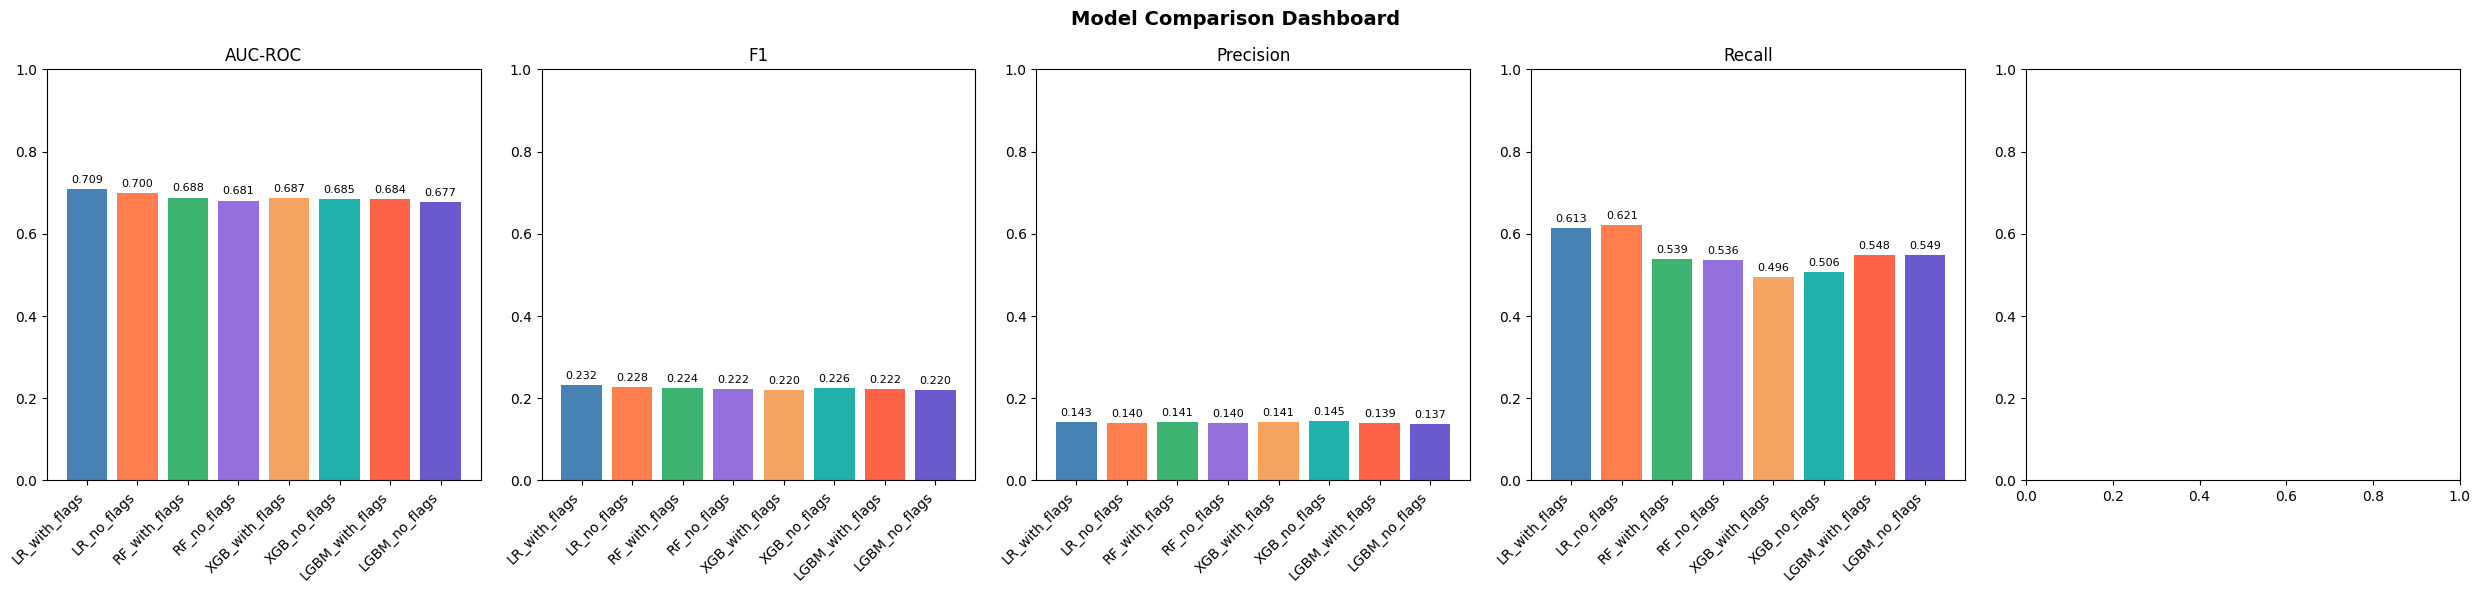

In [12]:
# comparing all models side by side across key metrics
metric_names = ['AUC-ROC', 'F1', 'Precision', 'Recall']
metric_keys  = ['test_auc', 'f1', 'precision', 'recall']
model_names  = list(results.keys())
colors       = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple',
                'sandybrown', 'lightseagreen', 'tomato', 'slateblue']

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
fig.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')

for ax, metric_name, metric_key in zip(axes, metric_names, metric_keys):
    values = [results[m][metric_key] for m in model_names]
    bars = ax.bar(model_names, values, color=colors)
    ax.set_title(metric_name)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 7.2 ROC Curves


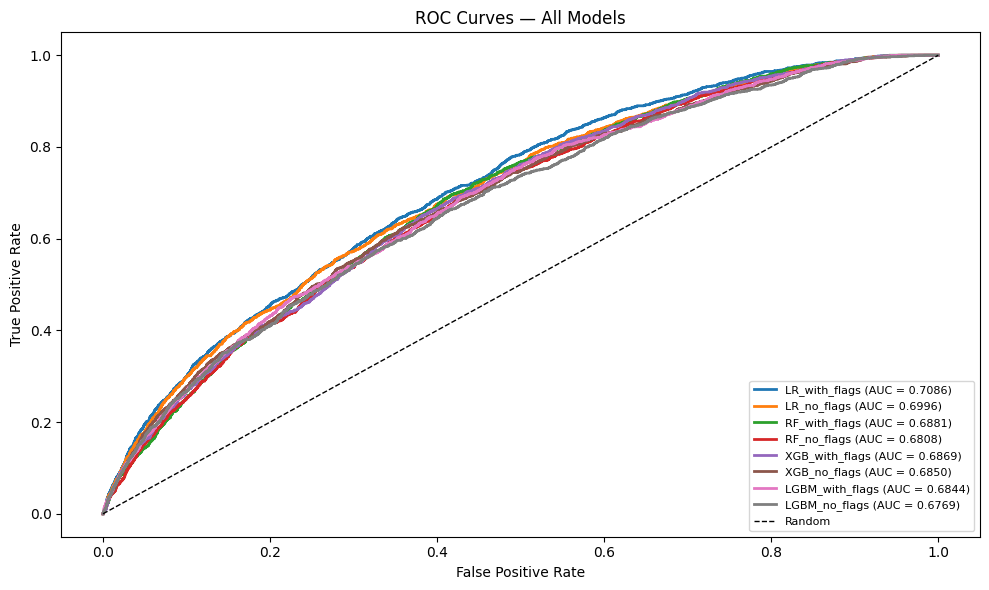

In [13]:
plt.figure(figsize=(10, 6))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Precision-Recall Curves

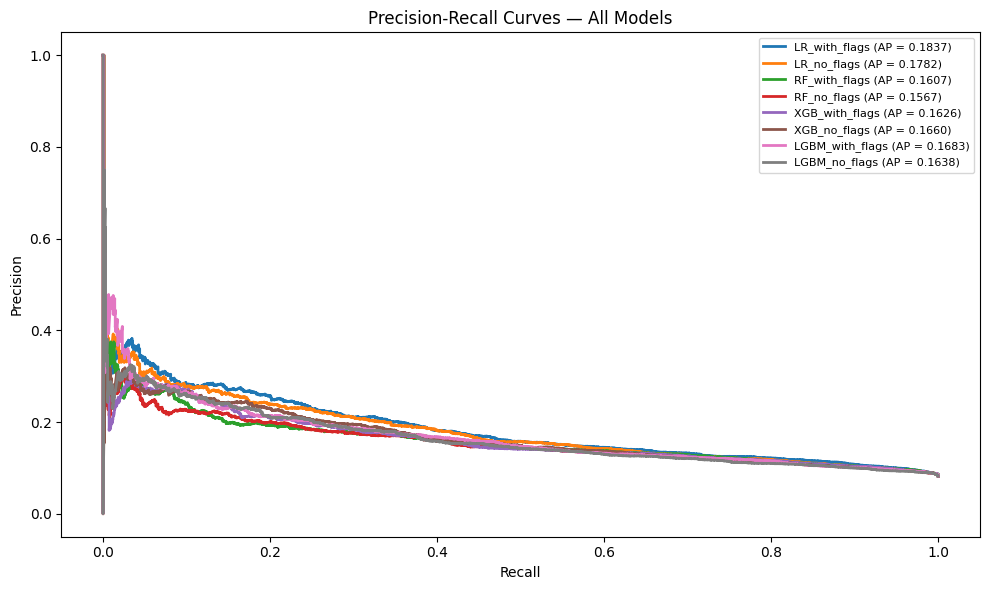

In [14]:
plt.figure(figsize=(10, 6))

for (name, res), color in zip(results.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall_vals, precision_vals, label=f"{name} (AP = {ap:.4f})", linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices

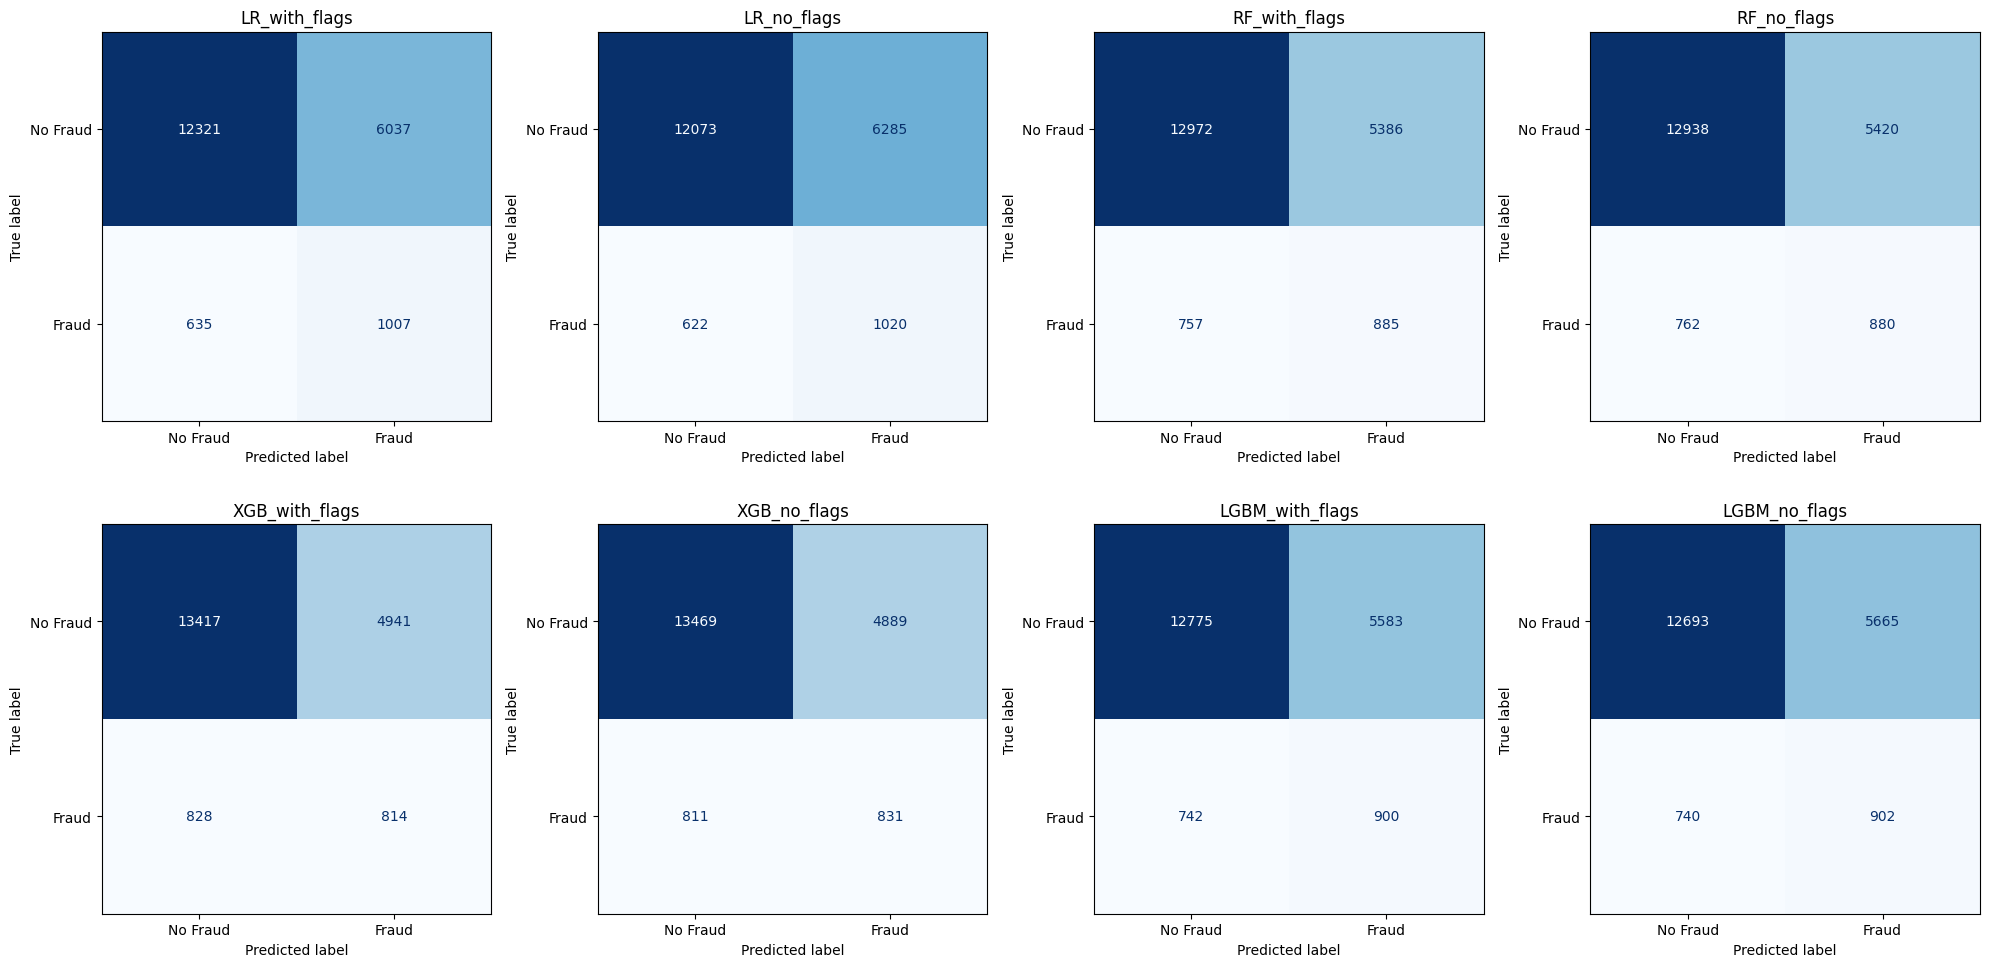

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 7.5 Summary Table

In [16]:
summary = pd.DataFrame({
    name: {
        'CV AUC Mean' : res['cv_auc'].mean().round(4),
        'CV AUC Std'  : res['cv_auc'].std().round(4),
        'Test AUC'    : round(res['test_auc'], 4),
        'F1'          : round(res['f1'], 4),
        'Precision'   : round(res['precision'], 4),
        'Recall'      : round(res['recall'], 4),
    }
    for name, res in results.items()
}).T

print(summary)

                 CV AUC Mean  CV AUC Std  Test AUC      F1  Precision  Recall
LR_with_flags         0.6991      0.0037    0.7086  0.2319     0.1430  0.6133
LR_no_flags           0.6847      0.0034    0.6996  0.2280     0.1396  0.6212
RF_with_flags         0.6789      0.0038    0.6881  0.2237     0.1411  0.5390
RF_no_flags           0.6661      0.0035    0.6808  0.2216     0.1397  0.5359
XGB_with_flags        0.6764      0.0042    0.6869  0.2201     0.1414  0.4957
XGB_no_flags          0.6637      0.0045    0.6850  0.2258     0.1453  0.5061
LGBM_with_flags       0.6710      0.0042    0.6844  0.2215     0.1388  0.5481
LGBM_no_flags         0.6605      0.0055    0.6769  0.2198     0.1374  0.5493


---
## 8. Hyperparameter Tuning
In this step, we optimize model performance by tuning key hyperparameters. The goal is to improve predictive power and generalization while maintaining model stability.
### 8.1 Logistic Regression Tuning
We tune the regularization strength and solver of Logistic Regression to improve performance while preserving interpretability.

In [17]:
#from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 50],
    'model__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    estimator=build_pipeline(
        model=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        is_logistic=True,
        drop_flags=False
    ),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("Best LR Params:", grid_lr.best_params_)
print("Best LR CV Score:", grid_lr.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best LR Params: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best LR CV Score: 0.6992192816675452


In [18]:
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

results['LR_tuned'] = {
    'pipeline'  : best_lr,
    'cv_auc'    : np.array([0.6982]),  # CV score from GridSearch output
    'test_auc'  : roc_auc_score(y_test, y_prob_lr),
    'f1'        : f1_score(y_test, y_pred_lr),
    'precision' : precision_score(y_test, y_pred_lr),
    'recall'    : recall_score(y_test, y_pred_lr),
    'y_pred'    : y_pred_lr,
    'y_prob'    : y_prob_lr,
}

### 8.2 XGBoost Tuning
We tune XGBoost as an alternative model to improve performance and robustness, especially for more complex patterns.

In [19]:
#import optuna
#from sklearn.model_selection import cross_val_score

def objective(trial):
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10)
    }

    model = build_pipeline(
        model=XGBClassifier(**params, eval_metric='logloss', use_label_encoder=False),
        is_logistic=False,
        drop_flags=False
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=3,
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print("Best XGB Params:", study.best_params)
print("Best XGB AUC:", study.best_value)

[I 2026-05-15 11:15:01,633] A new study created in memory with name: no-name-135334f3-e411-440d-847f-b18e4ba6eb6e
[I 2026-05-15 11:47:04,880] Trial 0 finished with value: 0.6772726788737095 and parameters: {'n_estimators': 268, 'max_depth': 4, 'learning_rate': 0.14871963925911766, 'subsample': 0.9294705245686257, 'colsample_bytree': 0.8227144738212123, 'scale_pos_weight': 6.108300623417647}. Best is trial 0 with value: 0.6772726788737095.
[I 2026-05-15 13:58:44,831] Trial 1 finished with value: 0.6794425361131373 and parameters: {'n_estimators': 233, 'max_depth': 4, 'learning_rate': 0.13854386214595485, 'subsample': 0.7193849005636905, 'colsample_bytree': 0.6766318611344047, 'scale_pos_weight': 6.405406299386986}. Best is trial 1 with value: 0.6794425361131373.
[I 2026-05-15 13:59:27,531] Trial 2 finished with value: 0.6834250430693899 and parameters: {'n_estimators': 217, 'max_depth': 4, 'learning_rate': 0.16316190124263522, 'subsample': 0.944256163029234, 'colsample_bytree': 0.672958

Best XGB Params: {'n_estimators': 164, 'max_depth': 4, 'learning_rate': 0.03114043825078472, 'subsample': 0.7000494395495146, 'colsample_bytree': 0.8432169650208973, 'scale_pos_weight': 2.2099969930276684}
Best XGB AUC: 0.700018885076659


In [20]:
print("LR Tuned:")
print(f"  ROC AUC: {results['LR_tuned']['test_auc']:.4f}")
print()

best_xgb = build_pipeline(
    model=XGBClassifier(**study.best_params, eval_metric='logloss', use_label_encoder=False),
    is_logistic=False,
    drop_flags=False
)
best_xgb.fit(X_train, y_train)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGB Tuned:")
print(f"  ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


LR Tuned:
  ROC AUC: 0.7092

XGB Tuned:
  ROC AUC: 0.7087


---
## 9. Threshold Tuning
Default 0.5 threshold is rarely optimal for fraud detection — we find the best threshold by maximizing F1 score on the validation set.

Best Threshold: 0.63
Best F1 Score:  0.2566


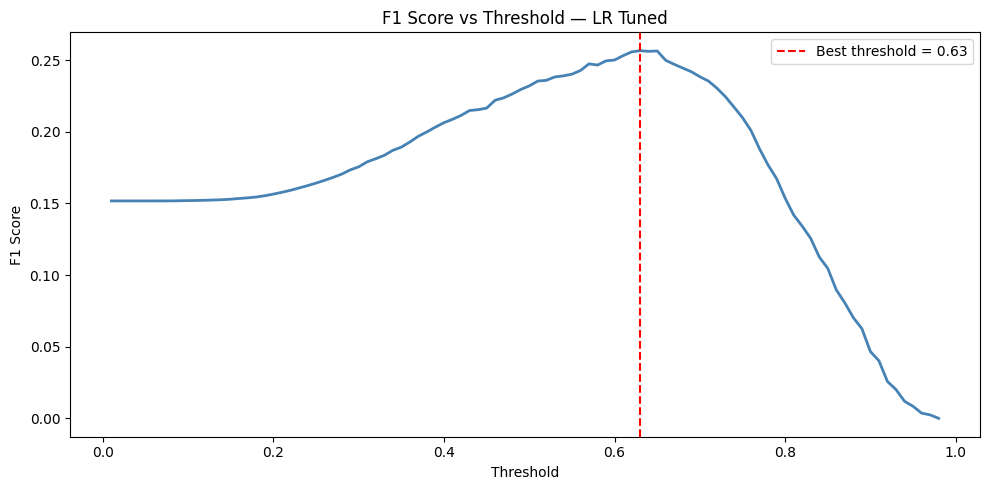

In [21]:
# use best tuned model
tuned_pipeline = results['LR_tuned']['pipeline']
y_prob_tuned   = results['LR_tuned']['y_prob']

# test different thresholds
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_tuned >= t).astype(int)) for t in thresholds]

# find best threshold
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f'Best Threshold: {best_threshold:.2f}')
print(f'Best F1 Score:  {best_f1:.4f}')

# visualize
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold — LR Tuned')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
y_pred_final = (y_prob_tuned >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(f'PR AUC:  {average_precision_score(y_test, y_prob_tuned):.4f}')

              precision    recall  f1-score   support

           0       0.94      0.87      0.90     18358
           1       0.20      0.36      0.26      1642

    accuracy                           0.83     20000
   macro avg       0.57      0.62      0.58     20000
weighted avg       0.88      0.83      0.85     20000

ROC AUC: 0.7092
PR AUC:  0.1839


---
## 10. Feature Importance (Logistic Regression)
In this step, we analyze feature importance using Logistic Regression coefficients to understand which features contribute most to fraud prediction.

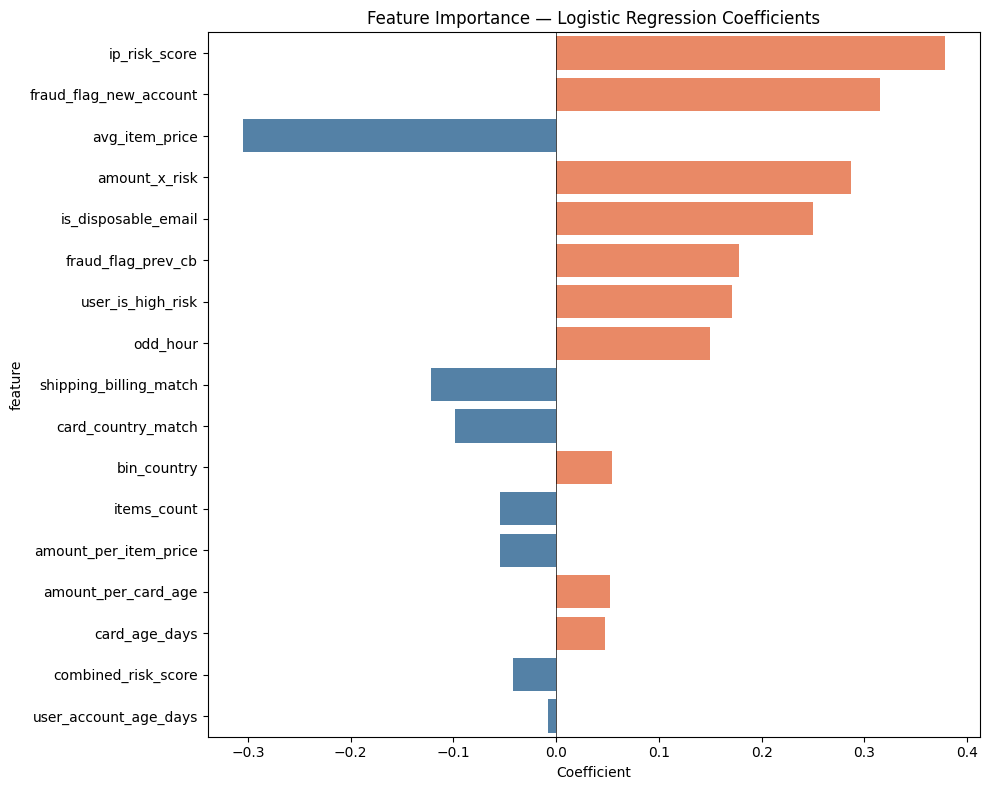

               feature  coefficient
         ip_risk_score     0.378403
fraud_flag_new_account     0.314823
        avg_item_price    -0.305083
         amount_x_risk     0.286522
   is_disposable_email     0.249756
    fraud_flag_prev_cb     0.177740
     user_is_high_risk     0.170865
              odd_hour     0.149595
shipping_billing_match    -0.121960
    card_country_match    -0.098304
           bin_country     0.054692
           items_count    -0.054684
 amount_per_item_price    -0.054406
   amount_per_card_age     0.052883
         card_age_days     0.047682
   combined_risk_score    -0.041879
 user_account_age_days    -0.007818


In [23]:
# extracting feature importance from best LR model using coefficients
lr_pipeline = results['LR_tuned']['pipeline']

feature_names = lr_pipeline.named_steps['feature_engineering'].transform(
    X_train.head(100)
).columns.tolist()

coefficients = lr_pipeline.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'feature'     : feature_names,
    'coefficient' : coefficients
}).assign(abs_coefficient=lambda x: x['coefficient'].abs())\
  .sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['coral' if c > 0 else 'steelblue' for c in feature_importance['coefficient']]
sns.barplot(x='coefficient', y='feature', data=feature_importance, palette=colors)
plt.title('Feature Importance — Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(feature_importance[['feature', 'coefficient']].to_string(index=False))

---
## 11. Error Analysis
Analyzing False Positives and False Negatives to understand where the model fails — this is critical for fraud detection as missing a fraud (FN) is more costly than a false alarm (FP).
### 11.1 False Negative Analysis — Missed Frauds

In [24]:
# identifying frauds that the model missed
y_pred_final = (results['LR_with_flags']['y_prob'] >= best_threshold).astype(int)
X_test_copy = X_test.copy()
X_test_copy['y_true']     = y_test.values
X_test_copy['y_pred']     = y_pred_final
X_test_copy['y_prob']     = results['LR_tuned']['y_prob']

false_negatives = X_test_copy[(X_test_copy['y_true'] == 1) & (X_test_copy['y_pred'] == 0)]
false_positives = X_test_copy[(X_test_copy['y_true'] == 0) & (X_test_copy['y_pred'] == 1)]

print(f'False Negatives (missed frauds): {len(false_negatives)}')
print(f'False Positives (false alarms):  {len(false_positives)}')

False Negatives (missed frauds): 1053
False Positives (false alarms):  2372


### 11.2 False Negative Profile

In [25]:
# what do missed frauds look like?
print("Missed Fraud Profile:")
print(false_negatives[['amount_aed', 'ip_risk_score', 'user_account_age_days']].describe().round(2))

Missed Fraud Profile:
       amount_aed  ip_risk_score  user_account_age_days
count     1053.00        1053.00                1053.00
mean       267.73          44.31                 750.59
std       1032.66          14.87                 620.20
min          4.94           2.60                -365.00
25%         41.42          33.70                 230.00
50%         86.66          44.50                 754.00
75%        176.91          55.00                1281.00
max      20929.35         100.00                1825.00


### 11.3 False Positive Profile


In [26]:
# what do false alarms look like?
print("False Alarm Profile:")
print(false_positives[['amount_aed', 'ip_risk_score', 'user_account_age_days']].describe().round(2))

False Alarm Profile:
       amount_aed  ip_risk_score  user_account_age_days
count     2372.00        2372.00                2372.00
mean       159.47          52.70                 367.37
std        377.44          16.47                 657.96
min          2.06           6.80                -365.00
25%         41.18          41.68                -173.00
50%         79.91          52.50                  19.50
75%        162.88          62.20                 904.75
max      12079.52         100.00                1825.00


### 11.4 Visualization

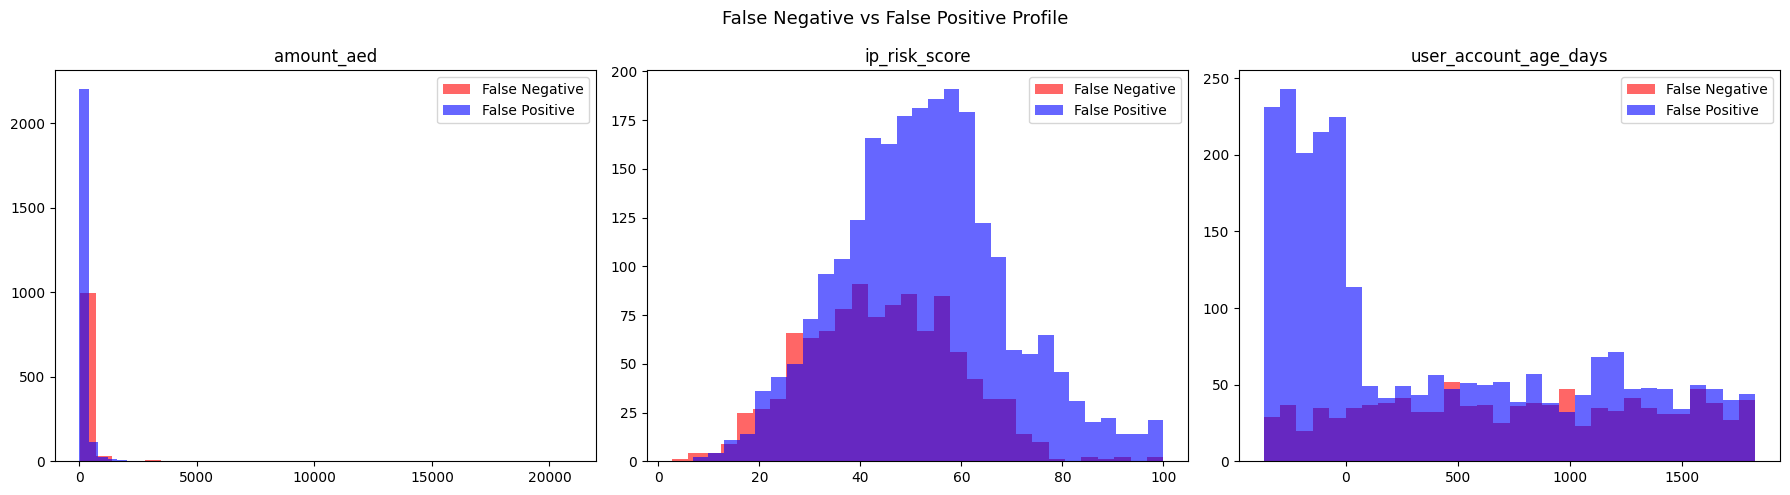

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['amount_aed', 'ip_risk_score', 'user_account_age_days']):
    ax.hist(false_negatives[col], bins=30, alpha=0.6, label='False Negative', color='red')
    ax.hist(false_positives[col], bins=30, alpha=0.6, label='False Positive', color='blue')
    ax.set_title(col)
    ax.legend()

plt.suptitle('False Negative vs False Positive Profile', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Save Best Model
Saving the trained pipeline to disk so it can be loaded and used in the FastAPI backend without retraining.

In [28]:
# saving the best pipeline — LR with flags


with open('../model/fraud_model8.pkl', 'wb') as f:
    cloudpickle.dump(results['LR_tuned']['pipeline'], f)

print("Saved with cloudpickle!")

Saved with cloudpickle!


In [29]:
joblib.dump(results['LR_tuned']['pipeline'], '../model/fraud_model7.pkl')
print("Saved with joblib!")

Saved with joblib!


In [30]:


# Check when the file was created
path = '../model/fraud_model7.pkl'
print("File exists:", os.path.exists(path))
print("Last modified:", pd.Timestamp.fromtimestamp(os.path.getmtime(path)))

# Verify FraudFeatureEngineer inside the pipeline
p = joblib.load(path)
fe = p.named_steps['feature_engineering']
print("user_stats_ exists?", hasattr(fe, 'user_stats_'))  # should be False
print("drop_cols_1 exists?", hasattr(fe, 'drop_cols_1'))  # should be True

File exists: True
Last modified: 2026-05-15 14:13:32.081844
user_stats_ exists? False
drop_cols_1 exists? True


## 13. Exporting Results to PostgreSQL

In this step, we persist our modeling results by exporting them to a **PostgreSQL** database. 

**Key Actions:**
* **Database Connection:** Established using `psycopg2` with local credentials.
* **Schema Definition:** A table named `model_results` is initialized to store metrics (AUC, F1, Precision, Recall).
* **Data Logging:** Each model's performance, including cross-validation and test set results, is saved with a timestamp for tracking history.

In [31]:
import psycopg2
from datetime import datetime

# Connect to PostgreSQL
conn = psycopg2.connect(
    host     = "localhost",
    database = "fraud_detection",
    user     = "postgres",
    password = "yeni123",
    port     = 5432
)

cursor = conn.cursor()

# Create table if it doesn't exist
cursor.execute('''
    CREATE TABLE IF NOT EXISTS model_results (
        id              SERIAL PRIMARY KEY,
        model_name      VARCHAR(50),
        cv_auc_mean     FLOAT,
        cv_auc_std      FLOAT,
        test_auc        FLOAT,
        f1              FLOAT,
        precision_score FLOAT,
        recall_score    FLOAT,
        with_flags      BOOLEAN,
        run_date        TIMESTAMP
    )
''')

# Delete old results before inserting new ones
cursor.execute('DELETE FROM model_results')
print("Old records deleted.")

# Insert fresh results for all models
for name, res in results.items():
    cursor.execute('''
        INSERT INTO model_results 
        (model_name, cv_auc_mean, cv_auc_std, test_auc, 
         f1, precision_score, recall_score, with_flags, run_date)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
    ''', (
        name,
        round(float(res['cv_auc'].mean()), 4),  # average CV AUC across 5 folds
        round(float(res['cv_auc'].std()),  4),  # stability — lower is better
        round(float(res['test_auc']),      4),  # final test set AUC
        round(float(res['f1']),            4),  # F1 score at best threshold
        round(float(res['precision']),     4),  # precision at best threshold
        round(float(res['recall']),        4),  # recall at best threshold
        False if 'no_flags' in name else True,  # whether fraud flags were used
        datetime.now()                          # timestamp of this run
    ))

# Commit all inserts and close connection
conn.commit()
cursor.close()
conn.close()
print(f"{len(results)} models saved to PostgreSQL.")

Old records deleted.
9 models saved to PostgreSQL.


## 14. Automated Dependency Management

This step ensures that the project environment can be easily reproduced by capturing all necessary libraries in a structured way.

**Key Actions:**
* **Dynamic Library Scanning:** A Python script parses the notebook's code cells to detect active `import` and `from` statements.
* **Smart Mapping:** Internal module names are mapped to their official distribution names (e.g., `psycopg2` is mapped to `psycopg2-binary` for better compatibility).
* **Organized Storage:** The `requirements.txt` file is automatically saved to a specific `../requirements/` directory to maintain a clean project structure.

In [32]:


# Updated file paths
input_notebook = 'modeling.ipynb'
output_dir = '../requirements'
output_file = os.path.join(output_dir, 'requirements.txt')

# Standard library modules to ignore
standard_libs = [
    'json', 'os', 're', 'sys', 'datetime', 'warnings', 'time', 'math', 'random'
]

# Mapping of import names to PyPI package names
package_mapping = {
    'sklearn': 'scikit-learn',
    'psycopg2': 'psycopg2-binary',
    'PIL': 'Pillow',
    'cv2': 'opencv-python'
}

def generate_requirements(notebook_path):
    try:
        # Create the directory if it doesn't exist
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            print(f"Created directory: {output_dir}")

        with open(notebook_path, 'r', encoding='utf-8') as f:
            nb = json.load(f)
        
        libraries = set()
        
        # Regex to find imports
        import_re = re.compile(r'^(?:import|from)\s+([a-zA-Z0-9_]+)', re.MULTILINE)

        for cell in nb.get('cells', []):
            if cell.get('cell_type') == 'code':
                source = "".join(cell.get('source', []))
                matches = import_re.findall(source)
                for lib in matches:
                    if lib not in standard_libs:
                        lib_name = package_mapping.get(lib, lib)
                        libraries.add(lib_name)

        # Write to the specific path: ../requirements/requirements.txt
        with open(output_file, 'w', encoding='utf-8') as f:
            for lib in sorted(libraries):
                f.write(f"{lib}\n")
        
        print(f"Successfully created: {output_file}")
        print("Libraries found:", sorted(libraries))

    except Exception as e:
        print(f"An error occurred: {e}")

# Run the function
generate_requirements(input_notebook)

Successfully created: ../requirements\requirements.txt
Libraries found: ['cloudpickle', 'joblib', 'lightgbm', 'matplotlib', 'numpy', 'optuna', 'pandas', 'psycopg2-binary', 'scikit-learn', 'seaborn', 'shap', 'xgboost']
